In [1]:
import sys
sys.path.append('../analysis')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
from MBN_Res_Constrn import MBN_RC
from ClusterTracking import SCTA

In [2]:
mbn=MBN_RC()

/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/MouseBrainLib/mb_communities.npz already exists
DataUtils initialized


/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/../Model/tES/tES_Adaptive.py:141: RuntimeWarning: divide by zero encountered in divide
  K_ = 1 / self.K


In [3]:
import pandas as pd

In [4]:
df = pd.read_pickle(r'../../data/Raw/PERI/lo_peri.bz2',compression='bz2')



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 131208 entries, (1, 0) to (993, 425)
Columns: 5000 entries, 0 to 4999
dtypes: float32(5000)
memory usage: 2.4 GB


#### Setting up names for outer index columns

In [6]:
df_reset = df.reset_index()

In [7]:
df_reset.head()

,level_0,level_1,0,1,2,3,4,5,6,7,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,5,0,0.157077,0.160598,0.164243,0.167994,0.171832,0.175742,0.179711,0.183728,...,0.657623,0.656920,0.656157,0.655335,0.654453,0.653508,0.652500,0.651427,0.650286,0.649074
1,5,1,0.014478,0.014080,0.013944,0.014074,0.014469,0.015114,0.015994,0.017091,...,0.377835,0.377250,0.376560,0.375769,0.374881,0.373902,0.372839,0.371695,0.370479,0.369196
2,5,2,0.149793,0.147797,0.145818,0.143863,0.141938,0.140049,0.138203,0.136404,...,0.456650,0.459205,0.461634,0.463936,0.466107,0.468149,0.470062,0.471849,0.473514,0.475060
3,5,3,0.198785,0.197699,0.196459,0.195061,0.193506,0.191792,0.189918,0.187888,...,0.431043,0.429522,0.427761,0.425767,0.423548,0.421113,0.418471,0.415630,0.412602,0.409398
4,5,4,0.152710,0.152665,0.152518,0.152271,0.151924,0.151476,0.150929,0.150284,...,0.550049,0.551696,0.553135,0.554368,0.555397,0.556229,0.556871,0.557334,0.557629,0.557769


In [8]:
df_reset.columns

Index(['level_0', 'level_1',         0,         1,         2,         3,
               4,         5,         6,         7,
       ...
            4990,      4991,      4992,      4993,      4994,      4995,
            4996,      4997,      4998,      4999],
      dtype='object', length=5002)

#### itr contains iteration numbers

In [9]:
itr=df_reset['level_0'].drop_duplicates()

In [10]:
df.loc[5].shape

(852, 5000)

#### Accessing each iteration local order data

In [70]:
itr.head(20)

0         5
852       8
1278      9
1704     11
2130     12
2556     14
2982     15
3834     16
4260     18
4686     19
5112     20
5538     22
5964     23
6390     24
6816     25
7242     27
7668     30
9372     31
10224    33
10650    34
Name: level_0, dtype: int64

In [71]:
df.loc[31]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.089722,0.088406,0.086918,0.085274,0.083492,0.081590,0.079591,0.077512,0.075374,0.073194,...,0.492313,0.491791,0.491597,0.491734,0.492199,0.492988,0.494096,0.495511,0.497222,0.499214
1,0.093261,0.094684,0.096013,0.097241,0.098363,0.099371,0.100259,0.101019,0.101644,0.102127,...,0.146825,0.143600,0.140529,0.137618,0.134870,0.132286,0.129869,0.127618,0.125534,0.123614
2,0.015987,0.016962,0.018037,0.019200,0.020440,0.021747,0.023111,0.024524,0.025976,0.027460,...,0.154409,0.151981,0.149834,0.147975,0.146409,0.145137,0.144158,0.143469,0.143063,0.142932
3,0.136122,0.141030,0.146182,0.151520,0.156990,0.162537,0.168111,0.173659,0.179136,0.184494,...,0.338550,0.339137,0.339530,0.339726,0.339725,0.339525,0.339126,0.338522,0.337713,0.336696
4,0.078589,0.076970,0.075302,0.073590,0.071838,0.070052,0.068236,0.066398,0.064545,0.062685,...,0.211164,0.207979,0.204862,0.201816,0.198848,0.195961,0.193161,0.190453,0.187840,0.185329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,0.058455,0.059199,0.060885,0.063381,0.066537,0.070207,0.074259,0.078578,0.083072,0.087663,...,0.413935,0.412914,0.411883,0.410852,0.409829,0.408822,0.407842,0.406898,0.405999,0.405155
422,0.132312,0.134249,0.135925,0.137335,0.138473,0.139338,0.139925,0.140232,0.140258,0.140000,...,0.155401,0.152295,0.149225,0.146196,0.143213,0.140280,0.137402,0.134581,0.131822,0.129129
423,0.154780,0.155839,0.156763,0.157551,0.158197,0.158697,0.159046,0.159240,0.159275,0.159148,...,0.187419,0.188133,0.188716,0.189170,0.189499,0.189708,0.189800,0.189780,0.189653,0.189423
424,0.088126,0.091939,0.095636,0.099201,0.102618,0.105872,0.108949,0.111838,0.114527,0.117004,...,0.203423,0.201884,0.200417,0.199019,0.197686,0.196411,0.195190,0.194015,0.192879,0.191776


In [63]:
df.loc[itr.iloc[0]]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.157077,0.160598,0.164243,0.167994,0.171832,0.175742,0.179711,0.183728,0.187782,0.191867,...,0.657623,0.656920,0.656157,0.655335,0.654453,0.653508,0.652500,0.651427,0.650286,0.649074
1,0.014478,0.014080,0.013944,0.014074,0.014469,0.015114,0.015994,0.017091,0.018388,0.019871,...,0.377835,0.377250,0.376560,0.375769,0.374881,0.373902,0.372839,0.371695,0.370479,0.369196
2,0.149793,0.147797,0.145818,0.143863,0.141938,0.140049,0.138203,0.136404,0.134660,0.132974,...,0.456650,0.459205,0.461634,0.463936,0.466107,0.468149,0.470062,0.471849,0.473514,0.475060
3,0.198785,0.197699,0.196459,0.195061,0.193506,0.191792,0.189918,0.187888,0.185701,0.183362,...,0.431043,0.429522,0.427761,0.425767,0.423548,0.421113,0.418471,0.415630,0.412602,0.409398
4,0.152710,0.152665,0.152518,0.152271,0.151924,0.151476,0.150929,0.150284,0.149541,0.148703,...,0.550049,0.551696,0.553135,0.554368,0.555397,0.556229,0.556871,0.557334,0.557629,0.557769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,0.303650,0.301352,0.299009,0.296628,0.294219,0.291791,0.289353,0.286915,0.284487,0.282078,...,0.234113,0.235636,0.237342,0.239231,0.241301,0.243551,0.245977,0.248576,0.251346,0.254282
422,0.153936,0.158379,0.162796,0.167178,0.171512,0.175788,0.179995,0.184122,0.188157,0.192091,...,0.242176,0.245676,0.249096,0.252437,0.255704,0.258898,0.262022,0.265077,0.268066,0.270989
423,0.087379,0.089307,0.091150,0.092914,0.094603,0.096223,0.097780,0.099279,0.100725,0.102122,...,0.126627,0.129883,0.133256,0.136712,0.140223,0.143758,0.147289,0.150791,0.154237,0.157606
424,0.128688,0.130899,0.133236,0.135694,0.138264,0.140939,0.143708,0.146561,0.149486,0.152470,...,0.185325,0.181611,0.177562,0.173178,0.168463,0.163420,0.158054,0.152371,0.146377,0.140078


In [64]:
df_dum=df.loc[itr.iloc[0]]

In [69]:
df_dum.shape

(852, 5000)

In [67]:
df_dum.iloc[0:426]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.157077,0.160598,0.164243,0.167994,0.171832,0.175742,0.179711,0.183728,0.187782,0.191867,...,0.657623,0.656920,0.656157,0.655335,0.654453,0.653508,0.652500,0.651427,0.650286,0.649074
1,0.014478,0.014080,0.013944,0.014074,0.014469,0.015114,0.015994,0.017091,0.018388,0.019871,...,0.377835,0.377250,0.376560,0.375769,0.374881,0.373902,0.372839,0.371695,0.370479,0.369196
2,0.149793,0.147797,0.145818,0.143863,0.141938,0.140049,0.138203,0.136404,0.134660,0.132974,...,0.456650,0.459205,0.461634,0.463936,0.466107,0.468149,0.470062,0.471849,0.473514,0.475060
3,0.198785,0.197699,0.196459,0.195061,0.193506,0.191792,0.189918,0.187888,0.185701,0.183362,...,0.431043,0.429522,0.427761,0.425767,0.423548,0.421113,0.418471,0.415630,0.412602,0.409398
4,0.152710,0.152665,0.152518,0.152271,0.151924,0.151476,0.150929,0.150284,0.149541,0.148703,...,0.550049,0.551696,0.553135,0.554368,0.555397,0.556229,0.556871,0.557334,0.557629,0.557769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,0.055827,0.062886,0.069901,0.076872,0.083799,0.090681,0.097518,0.104312,0.111064,0.117775,...,0.193850,0.194851,0.196076,0.197530,0.199215,0.201130,0.203272,0.205632,0.208202,0.210969
422,0.053405,0.051166,0.050897,0.052532,0.055801,0.060332,0.065759,0.071776,0.078147,0.084694,...,0.298411,0.299524,0.300687,0.301902,0.303168,0.304482,0.305843,0.307246,0.308685,0.310154
423,0.131883,0.133843,0.135908,0.138058,0.140272,0.142529,0.144811,0.147099,0.149378,0.151632,...,0.225173,0.221587,0.217780,0.213764,0.209552,0.205157,0.200591,0.195867,0.190995,0.185987
424,0.280691,0.278618,0.276301,0.273741,0.270938,0.267895,0.264616,0.261107,0.257372,0.253420,...,0.315025,0.310705,0.306097,0.301211,0.296053,0.290634,0.284960,0.279040,0.272882,0.266495


In [66]:
df_dum.iloc[426:852]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.356114,0.349664,0.343034,0.336236,0.329286,0.322202,0.315006,0.307718,0.300353,0.292928,...,0.398153,0.400118,0.401615,0.402710,0.403472,0.403964,0.404244,0.404363,0.404364,0.404281
1,0.054123,0.055622,0.057382,0.059369,0.061548,0.063889,0.066362,0.068938,0.071589,0.074289,...,0.165978,0.165334,0.164468,0.163395,0.162134,0.160704,0.159121,0.157400,0.155556,0.153599
2,0.109508,0.104260,0.098954,0.093601,0.088217,0.082820,0.077437,0.072096,0.066833,0.061695,...,0.314613,0.316603,0.318442,0.320141,0.321710,0.323154,0.324476,0.325674,0.326747,0.327691
3,0.151981,0.144855,0.137638,0.130346,0.122997,0.115613,0.108215,0.100827,0.093473,0.086179,...,0.196187,0.194920,0.193814,0.192872,0.192093,0.191475,0.191012,0.190700,0.190532,0.190502
4,0.072947,0.071248,0.069500,0.067704,0.065866,0.063991,0.062089,0.060168,0.058235,0.056295,...,0.225554,0.225468,0.225281,0.224991,0.224601,0.224112,0.223529,0.222859,0.222110,0.221290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,0.303650,0.301352,0.299009,0.296628,0.294219,0.291791,0.289353,0.286915,0.284487,0.282078,...,0.234113,0.235636,0.237342,0.239231,0.241301,0.243551,0.245977,0.248576,0.251346,0.254282
422,0.153936,0.158379,0.162796,0.167178,0.171512,0.175788,0.179995,0.184122,0.188157,0.192091,...,0.242176,0.245676,0.249096,0.252437,0.255704,0.258898,0.262022,0.265077,0.268066,0.270989
423,0.087379,0.089307,0.091150,0.092914,0.094603,0.096223,0.097780,0.099279,0.100725,0.102122,...,0.126627,0.129883,0.133256,0.136712,0.140223,0.143758,0.147289,0.150791,0.154237,0.157606
424,0.128688,0.130899,0.133236,0.135694,0.138264,0.140939,0.143708,0.146561,0.149486,0.152470,...,0.185325,0.181611,0.177562,0.173178,0.168463,0.163420,0.158054,0.152371,0.146377,0.140078


In [ ]:
df_reset.iloc[:, 0]

In [7]:
sample=df.loc[199]
sample.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.136975,0.134204,0.131344,0.128404,0.125396,0.122336,0.119240,0.116129,0.113025,0.109956,...,0.779370,0.777559,0.775767,0.774002,0.772270,0.770578,0.768934,0.767343,0.765813,0.764348
1,0.129716,0.131695,0.133592,0.135407,0.137142,0.138796,0.140372,0.141871,0.143294,0.144643,...,0.517156,0.517683,0.518297,0.518997,0.519782,0.520651,0.521602,0.522632,0.523740,0.524922
2,0.095875,0.097866,0.099842,0.101801,0.103744,0.105669,0.107577,0.109468,0.111340,0.113194,...,0.677610,0.677488,0.677400,0.677345,0.677322,0.677332,0.677374,0.677448,0.677553,0.677688
3,0.229542,0.228954,0.228346,0.227729,0.227118,0.226524,0.225960,0.225438,0.224971,0.224569,...,0.427083,0.429605,0.432269,0.435073,0.438013,0.441086,0.444286,0.447607,0.451043,0.454586
4,0.153012,0.154576,0.156041,0.157409,0.158681,0.159858,0.160942,0.161933,0.162835,0.163648,...,0.566630,0.566983,0.567424,0.567957,0.568581,0.569298,0.570108,0.571012,0.572010,0.573102


In [8]:
sample.shape

(426, 5000)

In [9]:
local_order=sample.T

In [10]:
local_order.shape

(5000, 426)

In [11]:
local_order=local_order.to_numpy()

In [12]:
local_order.shape

(5000, 426)

### Extracting local order data and finding entry time of nodes

In [7]:
df = pd.read_pickle(r'lo_fn.bz2',compression='bz2')

In [6]:
df_reset = df.reset_index()

In [7]:
itr=df_reset['level_0'].drop_duplicates()

In [8]:
itr_val=itr.values

In [9]:
itr_val

array([  1,   8,  17,  20,  28,  31,  35,  48,  52,  53,  58,  60,  62,
        65,  66,  75,  77,  80,  83,  85,  86,  90,  92,  94,  98,  99,
       100, 103, 105, 109, 110, 121, 122, 128, 138, 140, 151, 154, 156,
       157, 161, 167, 168, 169, 170, 176, 177, 187, 188, 193, 194, 198,
       207, 209, 212, 213, 214, 215, 219, 220, 221, 222, 228, 232, 234,
       237, 248, 251, 256, 258, 262, 263, 270, 271, 287, 291, 296, 304,
       307, 310, 312, 317, 322, 326, 329, 331, 335, 338, 339, 346, 354,
       357, 366, 367, 370, 371, 372, 386, 387, 389, 394, 398, 402, 410,
       417, 419, 424, 426, 427, 428, 430, 433, 438, 450, 451, 452, 453,
       457, 459, 466, 472, 474, 477, 478, 479, 482, 483, 484, 486, 492,
       494, 495, 499, 503, 509, 511, 512, 517, 519, 521, 526, 531, 534,
       537, 543, 548, 551, 554, 564, 567, 568, 571, 574, 575, 577, 578,
       588, 589, 591, 592, 602, 603, 604, 607, 608, 612, 613, 614, 617,
       625, 626, 637, 641, 653, 656, 658, 659, 660, 673, 679, 68

In [12]:
left_toe=[]
right_toe=[]
whole_toe=[]

In [14]:
#just put transition number in df.loc[]

df_dum=df.loc[1].T
local_order=df_dum.values
scta = SCTA(mbn.binary_conn, 
            local_order, 
            local_order_phase = None, 
            sync_thrsh=0.5)
scta.track_clusters()
scta.update_synchronization_cluster_stats()
whole_toe=list(scta.TIME_OF_ENTRY)
left_toe=list(scta.TIME_OF_ENTRY[0:213])
right_toe=list(scta.TIME_OF_ENTRY[213:426])

        

Cluster tracking complete!


In [21]:
whole_toe=scta.TIME_OF_ENTRY

### Trying to plot from Time of Entry and node_communities the plots
 Objective is to find out the time of entry of a particular node (after this the node does not move out) in the main cluster

#### Using time of entry

In [ ]:
s_list=sorted(list(whole_toe))
print(s_list)

(0.0, 5000.0)

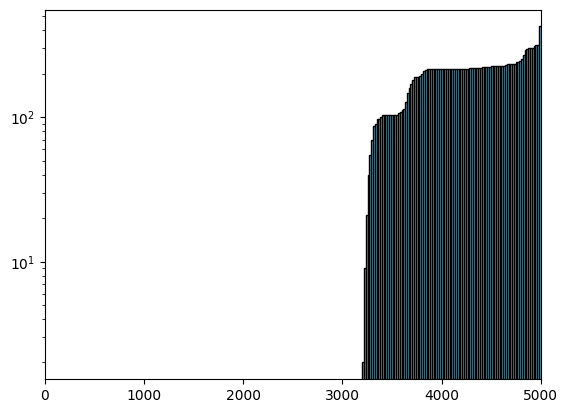

In [23]:
#pd.DataFrame(whole_toe.sort()).plot(kind='hist', cumulative=True, bins=100, histtype=u'step')
plt.hist(s_list, bins=100, cumulative=True, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.xlim(0, 5000)

(0.0, 5000.0)

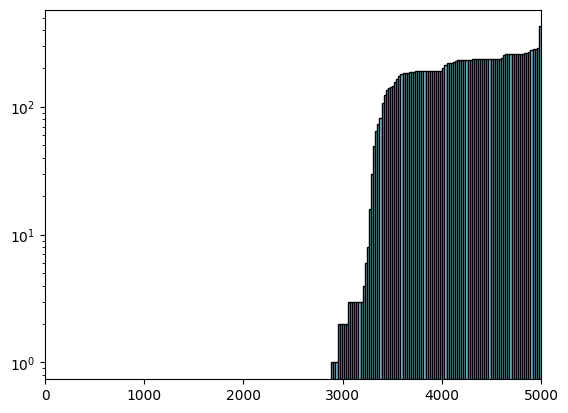

In [34]:
#pd.DataFrame(whole_toe.sort()).plot(kind='hist', cumulative=True, bins=100, histtype=u'step')
plt.hist(s_list, bins=100, cumulative=True, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.xlim(0, 5000)

#### Using node_communities

In [35]:
type(scta.node_communities)

numpy.ndarray

In [36]:
scta.node_communities.shape

(5000, 426)

In [49]:
whole_toe[0]

array([3306., 4999., 3424., 4984., 4999., 4999., 4963., 4978., 4977.,
       4999., 4130., 3313., 4893., 4640., 4560., 4911., 4895., 4603.,
       4025., 4916., 4039., 4620., 4062., 3279., 4999., 3370., 3276.,
       4009., 3346., 3358., 3213., 4021., 4029., 4608., 4910., 3742.,
       3379., 3438., 2955., 3338., 3229., 3326., 3254., 3333., 3276.,
       3338., 3348., 3350., 3360., 3415., 3542., 3600., 3397., 3404.,
       3411., 3408., 3425., 3419., 4012., 3547., 3372., 3287., 3272.,
       3340., 3306., 3466., 3494., 3313., 3301., 3352., 3326., 3608.,
       3561., 3567., 3536., 3274., 3393., 3300., 3469., 3333., 4144.,
       3272., 3322., 4845., 3536., 3598., 3552., 4955., 4022., 4001.,
       4284., 4312., 4039., 4656., 3427., 4027., 3452., 4641., 4999.,
       4902., 4640., 3444., 4634., 3417., 3377., 3401., 3445., 4908.,
       3328., 3265., 3329., 3405., 3496., 3403., 3384., 3316., 4635.,
       3326., 4021., 4921., 4999., 4999., 4894., 4890., 4999., 3557.,
       3573., 3580.,

#### NOTE

Check by putting time stamps near to final values the cluster which has got most of the nodes.

eg. here cluster 4 has got most nodes (out of 426), so this cluster was dominant

In [46]:
scta.node_communities[4800]

array([4., 4., 4., 0., 4., 4., 4., 4., 4., 0., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 0., 4., 4., 4., 4., 4., 0., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 0., 0., 0., 0., 0., 0., 0.,
       4., 0., 0., 4., 4., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 4., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 4., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 4., 4., 4., 0., 4., 0., 4., 4.,
       0., 4., 4., 4., 4.

One can check which cluster gets the highest nodes using hist plot too

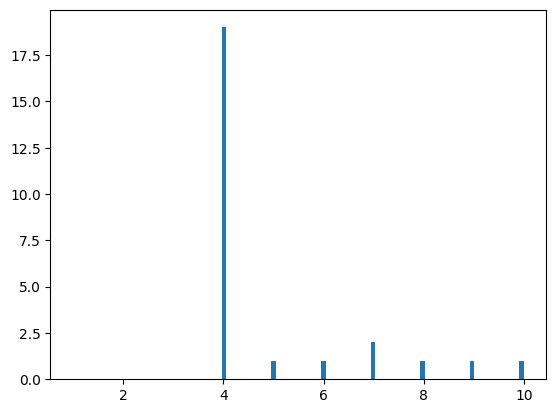

In [64]:
plt.hist(scta.node_communities[3280, :], bins=100, range=(1, 10));

In [53]:
scta.node_communities[3306][0]

4.0

In [55]:
for i in range(3306,5000):
    if scta.node_communities[i][0] != 4:
        print('TOE not valid')
    else:
        pass

In [63]:
scta.node_communities[1569][0]

0.0

In [ ]:
for i in range(0,3306):
    if scta.node_communities[i][0] != 0.0:
        print(f'TOE not valid at {i}')
    else:
        pass

#### NOTE: 
We can conclude that TOE is the last time after which the node never leaves that cluster.

Now, we will be using TOE to compare the node times of entry

In [4]:
import pandas as pd
df1  = pd.read_pickle(r'../../data/Raw/check_20/toe_fn_20.bz2',compression='bz2')
df2  = pd.read_pickle(r'../../data/Raw/check_20/toe_peri_20.bz2',compression='bz2')
df3  = pd.read_pickle(r'../../data/Raw/check_20/toe_enti_20.bz2',compression='bz2')
df4  = pd.read_pickle(r'../../data/Raw/check_20/toe_bla_20.bz2',compression='bz2')
df5  = pd.read_pickle(r'toe_orb_20.bz2',compression='bz2')
df6  = pd.read_pickle(r'../../data/Raw/check_20/toe_pir_20.bz2',compression='bz2')
df7 = pd.read_pickle(r'../../data/Raw/check_20/toe_re_20.bz2',compression='bz2')


In [73]:
len(peri_mean)

426

<Axes: >

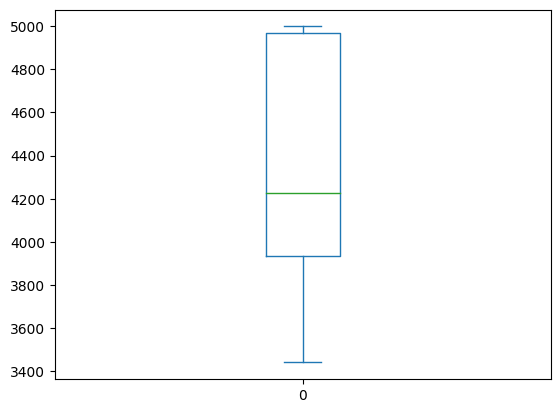

In [75]:
pd.DataFrame(peri_mean).plot(kind='box')

In [77]:
import seaborn as sns

<Axes: >

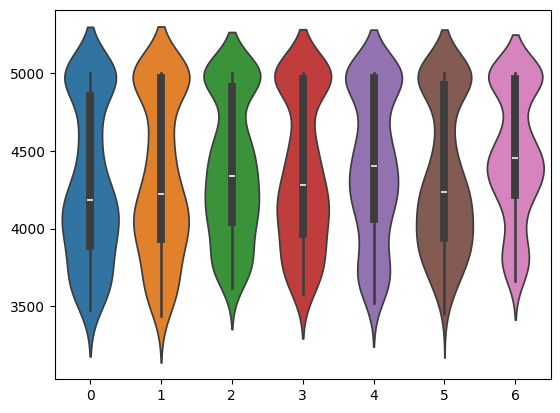

In [87]:
data=[fn_mean,peri_mean,enti_mean,bla_mean,orb_mean,pir_mean,re_mean]
sns.violinplot(data=data)
#sns.violinplot(pd.DataFrame(fn_mean))

<Axes: >

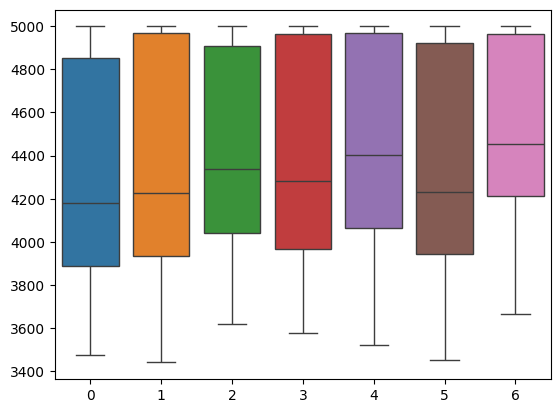

In [88]:
data=[fn_mean,peri_mean,enti_mean,bla_mean,orb_mean,pir_mean,re_mean]
sns.boxplot(data=data)

In [5]:
fn_mean=[]
fn_median=[]
for i in [36,249,53,266,64,277,23,236,43,256,113,326]:
    fn_mean.append(df1[i].mean())
    fn_median.append(df1[i].median())                

In [6]:
peri_mean=[]
peri_median=[]
for i in [36,249,53,266,64,277,23,236,43,256,113,326]:
    peri_mean.append(df2[i].mean())
    peri_median.append(df2[i].median())                

In [7]:
enti_mean=[]
enti_median=[]
for i in [36,249,53,266,64,277,23,236,43,256,113,326]:
    enti_mean.append(df3[i].mean())
    enti_median.append(df3[i].median())                

In [8]:
bla_mean=[]
bla_median=[]
for i in [36,249,53,266,64,277,23,236,43,256,113,326]:
    bla_mean.append(df4[i].mean())
    bla_median.append(df4[i].median())                

In [9]:
orb_mean=[]
orb_median=[]
for i in [36,249,53,266,64,277,23,236,43,256,113,326]:
    orb_mean.append(df5[i].mean())
    orb_median.append(df5[i].median())                

In [10]:
pir_mean=[]
pir_median=[]
for i in [36,249,53,266,64,277,23,236,43,256,113,326]:
    pir_mean.append(df6[i].mean())
    pir_median.append(df6[i].median())                

In [11]:
re_mean=[]
re_median=[]
for i in [36,249,53,266,64,277,23,236,43,256,113,326]:
    re_mean.append(df7[i].mean())
    re_median.append(df7[i].median())                

In [12]:
import matplotlib.pyplot as plt
import numpy as np

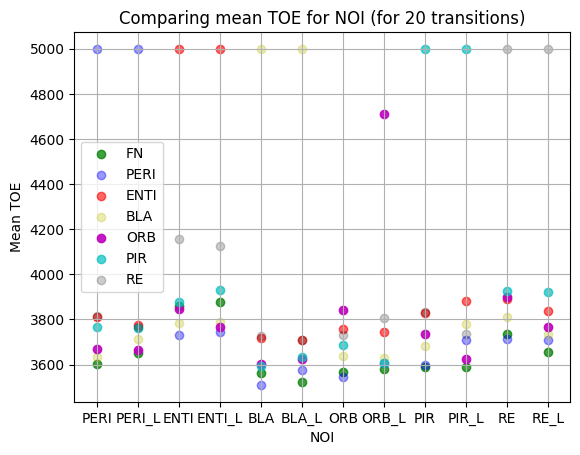

In [14]:
labels = ['PERI','PERI_L','ENTI','ENTI_L','BLA','BLA_L','ORB','ORB_L','PIR','PIR_L','RE','RE_L']
plt.scatter(labels,fn_mean,color='g', alpha=0.75,label='FN')
plt.scatter(labels,peri_mean,color='b', alpha=0.4,label='PERI')
plt.scatter(labels,enti_mean,color='r', alpha=0.6,label='ENTI')
plt.scatter(labels,bla_mean,color='y', alpha=0.3,label='BLA')
plt.scatter(labels,orb_mean,color='m', alpha=0.9,label='ORB')
plt.scatter(labels,pir_mean,color='c', alpha=0.7,label='PIR')
plt.scatter(labels,re_mean,color='k', alpha=0.2,label='RE')
plt.title('Comparing mean TOE for NOI (for 20 transitions)')
plt.xlabel("NOI")
plt.ylabel("Mean TOE")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
plt.savefig('toe_fn_1_r.png')

<Figure size 640x480 with 0 Axes>

#### Plotting avg TOE of all nodes

In [17]:
fn_mean=[]
fn_median=[]
for i in list(range(0,426)):
    fn_mean.append(df1[i].mean())
    fn_median.append(df1[i].median())  

In [18]:
peri_mean=[]
peri_median=[]
for i in list(range(0,426)):
    peri_mean.append(df2[i].mean())
    peri_median.append(df2[i].median())  

In [19]:
enti_mean=[]
enti_median=[]
for i in list(range(0,426)):
    enti_mean.append(df3[i].mean())
    enti_median.append(df3[i].median()) 

In [20]:
bla_mean=[]
bla_median=[]
for i in list(range(0,426)):
    bla_mean.append(df4[i].mean())
    bla_median.append(df4[i].median()) 

In [21]:
orb_mean=[]
orb_median=[]
for i in list(range(0,426)):
    orb_mean.append(df5[i].mean())
    orb_median.append(df5[i].median()) 

In [22]:
pir_mean=[]
pir_median=[]
for i in list(range(0,426)):
    pir_mean.append(df6[i].mean())
    pir_median.append(df6[i].median())  

In [23]:
re_mean=[]
re_median=[]
for i in list(range(0,426)):
    re_mean.append(df7[i].mean())
    re_median.append(df7[i].median())  

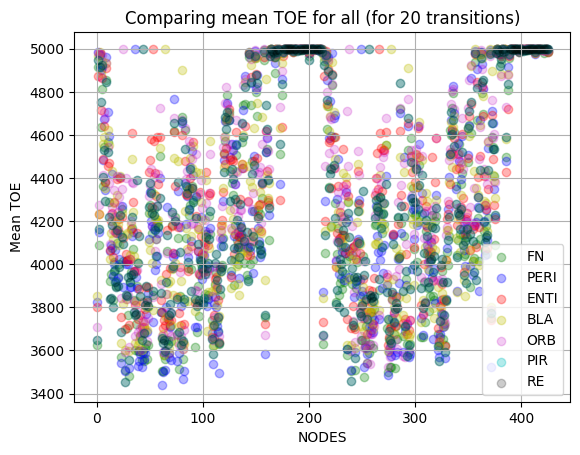

In [10]:
labels = list(range(0,426))
plt.scatter(labels,fn_mean,color='g', alpha=0.3,label='FN')
plt.scatter(labels,peri_mean,color='b', alpha=0.3,label='PERI')
plt.scatter(labels,enti_mean,color='r', alpha=0.3,label='ENTI')
plt.scatter(labels,bla_mean,color='y', alpha=0.3,label='BLA')
plt.scatter(labels,orb_mean,color='m', alpha=0.2,label='ORB')
plt.scatter(labels,pir_mean,color='c', alpha=0.3,label='PIR')
plt.scatter(labels,pir_mean,color='k', alpha=0.2,label='RE')
plt.title('Comparing mean TOE for all (for 20 transitions)')
plt.xlabel("NODES")
plt.ylabel("Mean TOE")
plt.legend()
plt.grid(True)
plt.show()

#### Zooming out above

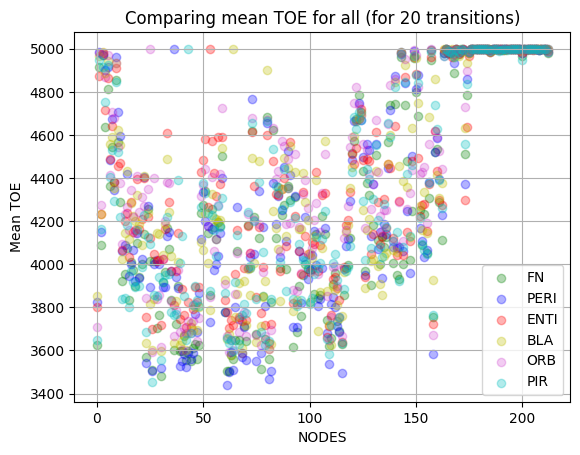

In [11]:
# Zoom in for one part of brain
labels = list(range(0,426))
plt.scatter(labels[0:213],fn_mean[0:213],color='g', alpha=0.3,label='FN')
plt.scatter(labels[0:213],peri_mean[0:213],color='b', alpha=0.3,label='PERI')
plt.scatter(labels[0:213],enti_mean[0:213],color='r', alpha=0.3,label='ENTI')
plt.scatter(labels[0:213],bla_mean[0:213],color='y', alpha=0.3,label='BLA')
plt.scatter(labels[0:213],orb_mean[0:213],color='m', alpha=0.2,label='ORB')
plt.scatter(labels[0:213],pir_mean[0:213],color='c', alpha=0.3,label='PIR')
plt.title('Comparing mean TOE for all (for 20 transitions)')
plt.xlabel("NODES")
plt.ylabel("Mean TOE")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
labels = list(range(0,426))
plt.scatter(labels,fn_mean,color='g', alpha=0.3,label='FN')
plt.scatter(labels,peri_mean,color='b', alpha=0.3,label='PERI')

In [24]:
import pickle

In [25]:
with open('../Mouse brain network/MouseBrainLib/mb_communities_dict.pickle', 'rb') as f:
    _x = pickle.load(f)

In [26]:
print(_x)

{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 28, 36, 60, 64, 67, 79, 87, 88, 89, 90, 91, 94, 109, 115, 118, 158, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 241, 242, 249, 273, 277, 280, 292, 300, 301, 302, 304, 305, 307, 322, 328, 371], 2: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 31, 32, 33, 34, 35, 37, 56, 57, 96, 97, 99, 102, 103, 106, 107, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 244, 245, 246, 247, 248, 250, 269, 270, 309, 310, 312, 315, 316, 319, 320], 3: [22, 23, 24, 25, 26, 27, 30, 42, 58, 59, 68, 104, 105, 108, 110, 112, 114, 116, 235, 236, 237, 238, 239, 240, 243, 255, 281, 317, 318, 321, 323, 325, 327, 329], 4: [29, 63, 65, 66, 73, 76, 78, 86, 92, 95, 122, 123, 125, 126, 127, 128, 129, 130, 133, 134, 135, 141, 276, 278, 279, 286, 289, 291, 299, 308, 324, 335, 336, 338, 339, 340, 341, 342, 343, 346, 347, 348, 354, 375], 6: [38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 53, 61, 62, 69, 70, 75, 77, 82, 251, 252, 253, 254, 256, 257, 258, 259, 260, 261, 266, 274,

In [27]:
_x.keys()

dict_keys([0, 2, 3, 4, 6, 7, 1, 5])

In [110]:
len(_x[1])

70

In [31]:
#### Creating data according to node cluster
fn_orbital=[]
fn_motor=[]
fn_visual=[]
fn_olfa=[]
fn_hthal=[]
fn_hcampus=[]
fn_midbrain=[]
fn_hindbrain=[]
mean=fn_mean
for i in _x[0]:
    fn_orbital.append(mean[i])

for i in _x[2]:
    fn_motor.append(mean[i])

for i in _x[3]:
    fn_visual.append(mean[i])

for i in _x[4]:
    fn_olfa.append(mean[i])

for i in _x[6]:
    fn_hthal.append(mean[i])

for i in _x[7]:
    fn_hcampus.append(mean[i])

for i in _x[1]:
    fn_midbrain.append(mean[i])

for i in _x[5]:
    fn_hindbrain.append(mean[i])

In [32]:
#### Creating data according to node cluster
peri_orbital=[]
peri_motor=[]
peri_visual=[]
peri_olfa=[]
peri_hthal=[]
peri_hcampus=[]
peri_midbrain=[]
peri_hindbrain=[]
mean=peri_mean
for i in _x[0]:
    peri_orbital.append(mean[i])

for i in _x[2]:
   peri_motor.append(mean[i])

for i in _x[3]:
    peri_visual.append(mean[i])

for i in _x[4]:
    peri_olfa.append(mean[i])

for i in _x[6]:
    peri_hthal.append(mean[i])

for i in _x[7]:
    peri_hcampus.append(mean[i])

for i in _x[1]:
    peri_midbrain.append(mean[i])

for i in _x[5]:
    peri_hindbrain.append(mean[i])

In [43]:
#### Creating data according to node cluster
enti_orbital=[]
enti_motor=[]
enti_visual=[]
enti_olfa=[]
enti_hthal=[]
enti_hcampus=[]
enti_midbrain=[]
enti_hindbrain=[]
mean=enti_mean
for i in _x[0]:
    enti_orbital.append(mean[i])

for i in _x[2]:
   enti_motor.append(mean[i])

for i in _x[3]:
    enti_visual.append(mean[i])

for i in _x[4]:
    enti_olfa.append(mean[i])

for i in _x[6]:
    enti_hthal.append(mean[i])

for i in _x[7]:
    enti_hcampus.append(mean[i])

for i in _x[1]:
    enti_midbrain.append(mean[i])

for i in _x[5]:
    enti_hindbrain.append(mean[i])

In [46]:
#### Creating data according to node cluster
bla_orbital=[]
bla_motor=[]
bla_visual=[]
bla_olfa=[]
bla_hthal=[]
bla_hcampus=[]
bla_midbrain=[]
bla_hindbrain=[]
mean=bla_mean
for i in _x[0]:
    bla_orbital.append(mean[i])

for i in _x[2]:
   bla_motor.append(mean[i])

for i in _x[3]:
    bla_visual.append(mean[i])

for i in _x[4]:
    bla_olfa.append(mean[i])

for i in _x[6]:
    bla_hthal.append(mean[i])

for i in _x[7]:
    bla_hcampus.append(mean[i])

for i in _x[1]:
    bla_midbrain.append(mean[i])

for i in _x[5]:
    bla_hindbrain.append(mean[i])

In [56]:
#### Creating data according to node cluster
pir_orbital=[]
pir_motor=[]
pir_visual=[]
pir_olfa=[]
pir_hthal=[]
pir_hcampus=[]
pir_midbrain=[]
pir_hindbrain=[]
mean=pir_mean
for i in _x[0]:
    pir_orbital.append(mean[i])

for i in _x[2]:
   pir_motor.append(mean[i])

for i in _x[3]:
    pir_visual.append(mean[i])

for i in _x[4]:
    pir_olfa.append(mean[i])

for i in _x[6]:
    pir_hthal.append(mean[i])

for i in _x[7]:
    pir_hcampus.append(mean[i])

for i in _x[1]:
    pir_midbrain.append(mean[i])

for i in _x[5]:
    pir_hindbrain.append(mean[i])

In [59]:
#### Creating data according to node cluster
re_orbital=[]
re_motor=[]
re_visual=[]
re_olfa=[]
re_hthal=[]
re_hcampus=[]
re_midbrain=[]
re_hindbrain=[]
mean=re_mean
for i in _x[0]:
    re_orbital.append(mean[i])

for i in _x[2]:
   re_motor.append(mean[i])

for i in _x[3]:
    re_visual.append(mean[i])

for i in _x[4]:
    re_olfa.append(mean[i])

for i in _x[6]:
    re_hthal.append(mean[i])

for i in _x[7]:
    re_hcampus.append(mean[i])

for i in _x[1]:
    re_midbrain.append(mean[i])

for i in _x[5]:
    re_hindbrain.append(mean[i])

In [60]:
len(_x[0])

56

/tmp/ipykernel_1295185/2438280631.py:195: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels( interval_labels)


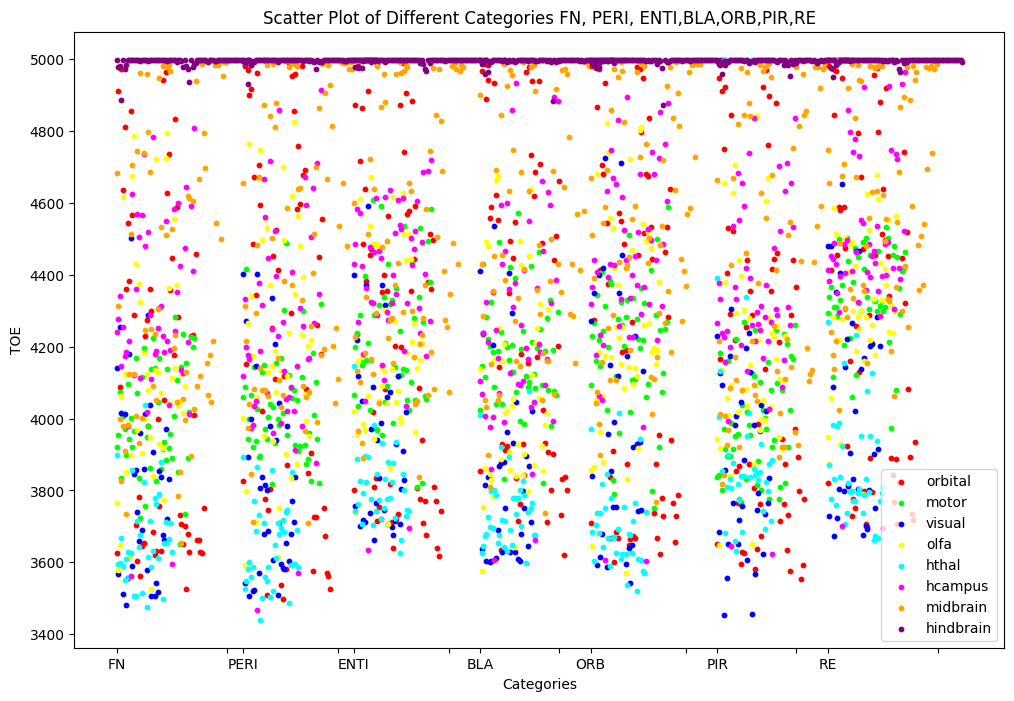

In [68]:
###### import matplotlib.pyplot as plt
import numpy as np

# Sample data
categories1 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data1 = {
    'orbital': fn_orbital,
    'motor': fn_motor,
    'visual': fn_visual,
    'olfa': fn_olfa, 
    'hthal': fn_hthal,
    'hcampus': fn_hcampus,
    'midbrain': fn_midbrain,
    'hindbrain': fn_hindbrain
}

categories2 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data2 = {
    'orbital': peri_orbital,
    'motor': peri_motor,
    'visual': peri_visual,
    'olfa': peri_olfa, 
    'hthal': peri_hthal,
    'hcampus': peri_hcampus,
    'midbrain': peri_midbrain,
    'hindbrain': peri_hindbrain
}

categories3 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data3 = {
    'orbital': enti_orbital,
    'motor': enti_motor,
    'visual': enti_visual,
    'olfa': enti_olfa, 
    'hthal': enti_hthal,
    'hcampus': enti_hcampus,
    'midbrain': enti_midbrain,
    'hindbrain': enti_hindbrain
}


categories4 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data4 = {
    'orbital': bla_orbital,
    'motor': bla_motor,
    'visual': bla_visual,
    'olfa': bla_olfa, 
    'hthal': bla_hthal,
    'hcampus': bla_hcampus,
    'midbrain': bla_midbrain,
    'hindbrain': bla_hindbrain
}

categories5 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data5 = {
    'orbital': orb_orbital,
    'motor': orb_motor,
    'visual': orb_visual,
    'olfa': orb_olfa, 
    'hthal': orb_hthal,
    'hcampus': orb_hcampus,
    'midbrain': orb_midbrain,
    'hindbrain': orb_hindbrain
}

categories6 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data6 = {
    'orbital': pir_orbital,
    'motor': pir_motor,
    'visual': pir_visual,
    'olfa': pir_olfa, 
    'hthal': pir_hthal,
    'hcampus': pir_hcampus,
    'midbrain': pir_midbrain,
    'hindbrain': pir_hindbrain
}


categories7 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data7 = {
    'orbital': re_orbital,
    'motor': re_motor,
    'visual': re_visual,
    'olfa': re_olfa, 
    'hthal': re_hthal,
    'hcampus': re_hcampus,
    'midbrain': re_midbrain,
    'hindbrain': re_hindbrain
}

#use this set of colors for paper
#colors = ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]
#use this set of colors for more informative
colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
#colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
# Plotting
fig, ax = plt.subplots(figsize=(12,8))
for i,category in enumerate(categories1):
    y = data1[category]
    x = list(range(0,len(data1[category])))

     # Add jitter to x-values
    x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)], label=category)
    #x = np.random.normal(i + 1, 0.04, len(y))
    #ax.scatter(x,y, color=colors[i % len(colors)], label=category)
    #ax[0,1].scatter(x,y, color=colors[i % len(colors)], label=category)

for i,category in enumerate(categories2):
    y = data2[category]
    x = list(range(80,80+len(data2[category])))

     # Add jitter to x-values
    x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])

for i,category in enumerate(categories3):
    y = data3[category]
    x = list(range(150,150+len(data3[category])))

     # Add jitter to x-values
    x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])

for i,category in enumerate(categories4):
    y = data4[category]
    x = list(range(230,230+len(data4[category])))

     # Add jitter to x-values
    x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])


for i,category in enumerate(categories5):
    y = data5[category]
    x = list(range(300,300+len(data5[category])))

     # Add jitter to x-values
    x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])


for i,category in enumerate(categories6):
    y = data6[category]
    x = list(range(380,380+len(data6[category])))

     # Add jitter to x-values
    x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])

for i,category in enumerate(categories7):
    y = data7[category]
    x = list(range(450,450+len(data7[category])))

     # Add jitter to x-values
    x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])
custom_ticks = [0, 70,80,140,150,210,230,280,300,360,380,430,450,520]
interval_labels = [ 'FN', '', 'PERI', '', 'ENTI', '', 'BLA', '', 'ORB', '', 'PIR', '', 'RE']
ax.set_xticklabels( interval_labels)
ax.set_xticks(custom_ticks)
ax.set_ylabel('TOE')
ax.set_xlabel('Categories')
ax.legend()

# Add title for clarity
plt.title('Scatter Plot of Different Categories FN, PERI, ENTI,BLA,ORB,PIR,RE')

# Show the plot
plt.show()


In [64]:
plt.savefig('my_plot.png')

<Figure size 640x480 with 0 Axes>

#### Plotting only mean TOE per community for a particular network

In [100]:
_x.keys()

dict_keys([0, 2, 3, 4, 6, 7, 1, 5])

In [139]:
d_mean=[]
for i in _x[0]:
    d_mean.append(df1[i].mean())
    orb_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df1[i].mean())
    motor_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[3]:
    d_mean.append(df1[i].mean())
    vis_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df1[i].mean())
    olfa_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df1[i].mean())
    hthal_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df1[i].mean())
    hcampus_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df1[i].mean())
    midbrain_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df1[i].mean())
    hindbrain_mean_fn=sum(d_mean)/len(d_mean)

In [140]:
d_mean=[]
for i in _x[0]:
    d_mean.append(df2[i].mean())
    orb_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df2[i].mean())
    motor_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[3]:
    d_mean.append(df2[i].mean())
    vis_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df2[i].mean())
    olfa_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df2[i].mean())
    hthal_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df2[i].mean())
    hcampus_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df2[i].mean())
    midbrain_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df2[i].mean())
    hindbrain_mean_peri=sum(d_mean)/len(d_mean)

In [141]:
d_mean=[]
for i in _x[0]:
    d_mean.append(df3[i].mean())
    orb_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df3[i].mean())
    motor_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[3]:
    d_mean.append(df3[i].mean())
    vis_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df3[i].mean())
    olfa_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df3[i].mean())
    hthal_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df3[i].mean())
    hcampus_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df3[i].mean())
    midbrain_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df3[i].mean())
    hindbrain_mean_enti=sum(d_mean)/len(d_mean)

In [143]:
d_mean=[]
for i in _x[0]:
    d_mean.append(df4[i].mean())
    orb_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df4[i].mean())
    motor_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[3]:
    d_mean.append(df4[i].mean())
    vis_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df4[i].mean())
    olfa_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df4[i].mean())
    hthal_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df4[i].mean())
    hcampus_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df4[i].mean())
    midbrain_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df4[i].mean())
    hindbrain_mean_bla=sum(d_mean)/len(d_mean)

In [148]:
d_mean=[]
for i in _x[0]:
    d_mean.append(df5[i].mean())
    orb_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df5[i].mean())
    motor_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[3]:
    d_mean.append(df5[i].mean())
    vis_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df5[i].mean())
    olfa_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df5[i].mean())
    hthal_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df5[i].mean())
    hcampus_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df5[i].mean())
    midbrain_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df5[i].mean())
    hindbrain_mean_orb=sum(d_mean)/len(d_mean)

In [151]:
d_mean=[]
for i in _x[0]:
    d_mean.append(df6[i].mean())
    orb_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df6[i].mean())
    motor_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[3]:
    d_mean.append(df6[i].mean())
    vis_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df6[i].mean())
    olfa_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df6[i].mean())
    hthal_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df6[i].mean())
    hcampus_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df6[i].mean())
    midbrain_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df6[i].mean())
    hindbrain_mean_pir=sum(d_mean)/len(d_mean)

In [155]:
d_mean=[]
for i in _x[0]:
    d_mean.append(df7[i].mean())
    orb_mean_re=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df7[i].mean())
    motor_mean_re=sum(d_mean)/len(d_mean)

for i in _x[3]:
    d_mean.append(df7[i].mean())
    vis_mean_re=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df7[i].mean())
    olfa_mean_re=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df7[i].mean())
    hthal_mean_re=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df7[i].mean())
    hcampus_mean_re=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df7[i].mean())
    midbrain_mean_re=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df7[i].mean())
    hindbrain_mean_re=sum(d_mean)/len(d_mean)

In [ ]:
categories1 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data1 = {
    'orbital': orb_mean_fn,
    'motor': motor_mean_fn,
    'visual': vis_mean_fn,
    'olfa': olfa_mean_fn, 
    'hthal': hthal_mean_fn,
    'hcampus': hcampus_mean_fn,
    'midbrain': midbrain_mean_fn,
    'hindbrain': hindbrain_mean_fn
}

categories2 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data2 = {
    'orbital': orb_mean_peri,
    'motor': motor_mean_peri,
    'visual': vis_mean_peri,
    'olfa': olfa_mean_peri, 
    'hthal': hthal_mean_peri,
    'hcampus': hcampus_mean_peri,
    'midbrain': midbrain_mean_peri,
    'hindbrain': hindbrain_mean_peri
}

categories3 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data3 = {
    'orbital': orb_mean_enti,
    'motor': motor_mean_enti,
    'visual': vis_mean_enti,
    'olfa': olfa_mean_enti, 
    'hthal': hthal_mean_enti,
    'hcampus': hcampus_mean_enti,
    'midbrain': midbrain_mean_enti,
    'hindbrain': hindbrain_mean_enti
}

categories4 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data4 = {
    'orbital': orb_mean_bla,
    'motor': motor_mean_bla,
    'visual': vis_mean_bla,
    'olfa': olfa_mean_bla, 
    'hthal': hthal_mean_bla,
    'hcampus': hcampus_mean_bla,
    'midbrain': midbrain_mean_bla,
    'hindbrain': hindbrain_mean_bla
}


categories5 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data5 = {
    'orbital': orb_mean_orb,
    'motor': motor_mean_orb,
    'visual': vis_mean_orb,
    'olfa': olfa_mean_orb, 
    'hthal': hthal_mean_orb,
    'hcampus': hcampus_mean_orb,
    'midbrain': midbrain_mean_orb,
    'hindbrain': hindbrain_mean_orb
}


categories6 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data6 = {
    'orbital': orb_mean_pir,
    'motor': motor_mean_pir,
    'visual': vis_mean_pir,
    'olfa': olfa_mean_pir, 
    'hthal': hthal_mean_pir,
    'hcampus': hcampus_mean_pir,
    'midbrain': midbrain_mean_pir,
    'hindbrain': hindbrain_mean_pir
}


categories7 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data7 = {
    'orbital': orb_mean_re,
    'motor': motor_mean_re,
    'visual': vis_mean_re,
    'olfa': olfa_mean_re, 
    'hthal': hthal_mean_re,
    'hcampus': hcampus_mean_re,
    'midbrain': midbrain_mean_re,
    'hindbrain': hindbrain_mean_re
}

#colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
# Plotting
fig, ax = plt.subplots(figsize=(12,8))
for i,category in enumerate(categories1):
    y = data1[category]
    x='FN'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8,label=category)


for i,category in enumerate(categories2):
    y = data2[category]
    x='PERI'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories3):
    y = data3[category]
    x='ENTI'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories4):
    y = data4[category]
    x='BLA'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories5):
    y = data5[category]
    x='ORB'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories6):
    y = data6[category]
    x='PIR'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)

for i,category in enumerate(categories7):
    y = data7[category]
    x='RE'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


custom_ticks=[0,1,2,3,4,5,6]
ax.set_xticks(custom_ticks)
ax.set_ylabel('TOE')
ax.set_xlabel('Categories')
ax.legend()

In [128]:
len(y)

56

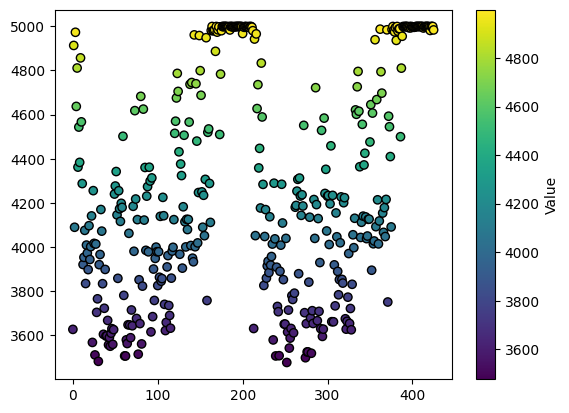

In [85]:
labels = list(range(0,426))
plt.scatter(labels, fn_mean, c=fn_mean, cmap='viridis', edgecolor='k')
plt.colorbar(label='Value') 


#### Plot to see transition from iteration data

In [35]:
#read iteration data
df_itr=pd.read_pickle(r'../../data/Raw/ORBI/itr_data_orbi.bz2')

In [36]:
#read local order data to find iteration number which has transition
df_loc=pd.read_pickle(r'../../data/Raw/ORBI/l200.bz2')

In [37]:
# read 
df_reset = df_loc.reset_index()
# reset outer index values i.e iteration numbers
itr=df_reset['level_0'].drop_duplicates()
# itr_val contains iteration numbers which had transitions
itr_val=itr.values
itr_val[0:20]

array([ 0,  1,  6,  8, 12, 15, 16, 17, 18, 19, 21, 22, 24, 25, 27, 28, 29,
       34, 38, 41])

In [51]:
df_loc.loc[19].shape

(1278, 5000)

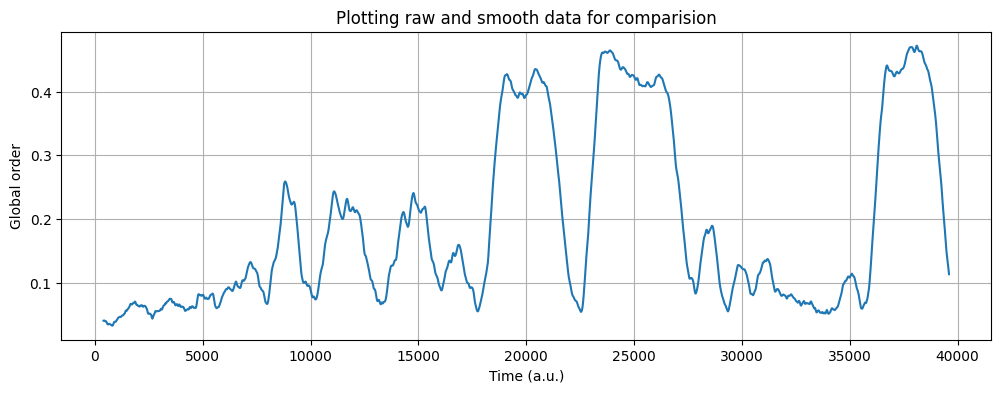

In [45]:
dt=0.05
#put  iteration number for which you want to plot
df_smooth=df_itr['19'].rolling(window=800, center=True).mean()

#defining time and timesteps for data
time_steps = list(range(0,df_smooth.shape[0]))   
time=np.multiply(time_steps,dt)

#plot the iteration to see transitions
#To plot comparision, uncomment
f = plt.figure(figsize=(12, 4))
plt.title("Plotting raw and smooth data for comparision") 

sync_smooth = df_smooth

plt.plot(time_steps,sync_smooth)
plt.ylabel("Global order")
plt.xlabel("Time (a.u.)")
plt.grid(True)
plt.show()

## Proper code to read local order data from the dataframe

In [110]:
left_toe=[]
right_toe=[]
whole_toe=[]
node_communities=[]
df_nc=pd.DataFrame()
tr_count=0
count=0
for x in itr_val[0:2]:
    df_dum=df.loc[x].T
    if df_dum.shape[1]/426==1:
        tr_count+=1
        local_order=df_dum.values
        scta = SCTA(mbn.binary_conn, 
            local_order, 
            local_order_phase = None, 
            sync_thrsh=0.5)
        scta.track_clusters()
        scta.update_synchronization_cluster_stats()
        left_toe.append(list(scta.TIME_OF_ENTRY[0:213]))
        right_toe.append(list(scta.TIME_OF_ENTRY[213:426]))
        whole_toe.append(list(scta.TIME_OF_ENTRY))
        node_communities.append(list(scta.node_communities))
        #df_dum =pd.DataFrame(node_communities))
        df_nc=pd.DataFrame(node_communities)
        print(f'{tr_count} Cluster track complete for transition {x}')
    else:
        
        f_limit=426
        df_dum=df_dum.T
        #i is count of number of transitions
        i=df_dum.shape[0]/426
        while count<i:
            tr_count+=1
            df_ext=df_dum.iloc[0+(f_limit*count):426+(f_limit*count)]
            df_ext=df_ext.T
            local_order=df_ext.values
            scta = SCTA(mbn.binary_conn, 
            local_order, 
            local_order_phase = None, 
            sync_thrsh=0.5)
            scta.track_clusters()
            scta.update_synchronization_cluster_stats()
            left_toe.append(list(scta.TIME_OF_ENTRY[0:213]))
            right_toe.append(list(scta.TIME_OF_ENTRY[213:426]))
            whole_toe.append(list(scta.TIME_OF_ENTRY))
            
            
            print(f'{tr_count} Cluster track complete for transition {x}')
            
            count+=1
    
    
            
            
l_toe_df=pd.DataFrame(left_toe)
r_toe_df=pd.DataFrame(right_toe)
whole_toe_df = pd.DataFrame(whole_toe)
            
            
        
        
        
        
        
        
    


Cluster tracking complete!
1 Cluster track complete for transition 1
Cluster tracking complete!
2 Cluster track complete for transition 8


In [121]:
len(node_communities[0])

5000

In [135]:

l=[[[1,2,3],[7,8,9],[3,4,5]]]

In [125]:
len(node_communities)

2

In [132]:
len(l[0])

3

In [136]:
ldf=pd.DataFrame(l)

In [137]:
ldf.head()

,0,1,2
0,"[1, 2, 3]","[7, 8, 9]","[3, 4, 5]"


In [139]:
l[0]

[[1, 2, 3], [7, 8, 9], [3, 4, 5]]

In [111]:
df_nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Columns: 5000 entries, 0 to 4999
dtypes: object(5000)
memory usage: 78.2+ KB


In [112]:
df_nc.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,"[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, ..."
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,"[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."


In [114]:
df_nc.iloc[-1].shape

(5000,)

In [109]:
type(scta.node_communities)

numpy.ndarray

In [105]:
scta.node_communities

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.]])

In [13]:
whole_toeperi_df=whole_toeperi_df.astype(np.float32)
whole_toeperi_df.to_pickle('toe_10_peri.bz2',compression='bz2')

In [12]:
whole_toeperi_df.head()

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,3294.0,4936.0,3647.0,4942.0,4999.0,4823.0,4646.0,4905.0,3651.0,4886.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
1,3718.0,4999.0,4966.0,4999.0,4999.0,4999.0,4999.0,4999.0,4970.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
2,4828.0,4999.0,4819.0,4999.0,4999.0,4999.0,4999.0,4999.0,4832.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
3,3387.0,4916.0,4531.0,4999.0,4821.0,4887.0,4822.0,4826.0,4854.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
4,3372.0,4999.0,3448.0,4880.0,3565.0,4784.0,3453.0,4797.0,3535.0,4787.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0


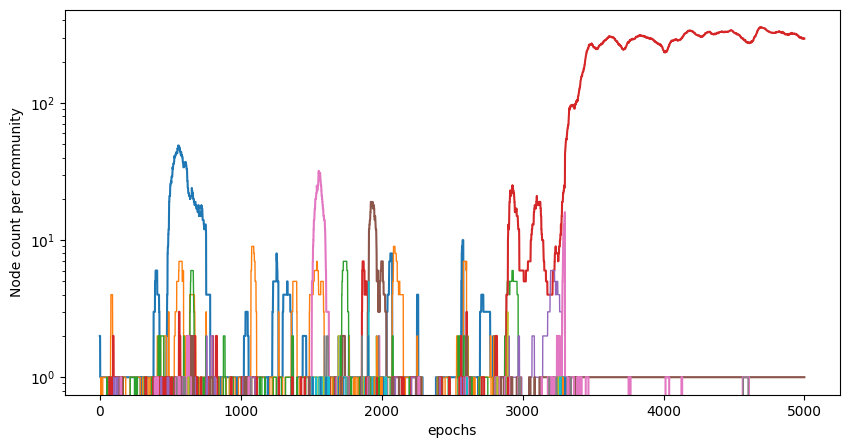

In [19]:
f = plt.figure(figsize=(10, 5))
for i in range(scta.MIN_CLUSTER_ID, scta.MAX_CLUSTER_ID):
    if np.max(scta.count_per_sync_cluster[:,i]) > 10:
        plt.plot(np.linspace(0, scta.window_size-1, scta.window_size), 
                 scta.count_per_sync_cluster[:,i], label=""+str(i))
    else:
        plt.plot(np.linspace(0, scta.window_size-1, scta.window_size), 
                 scta.count_per_sync_cluster[:,i], linewidth=1)

plt.xlabel("epochs")
plt.ylabel("Node count per community")
plt.yscale("log")
plt.show()

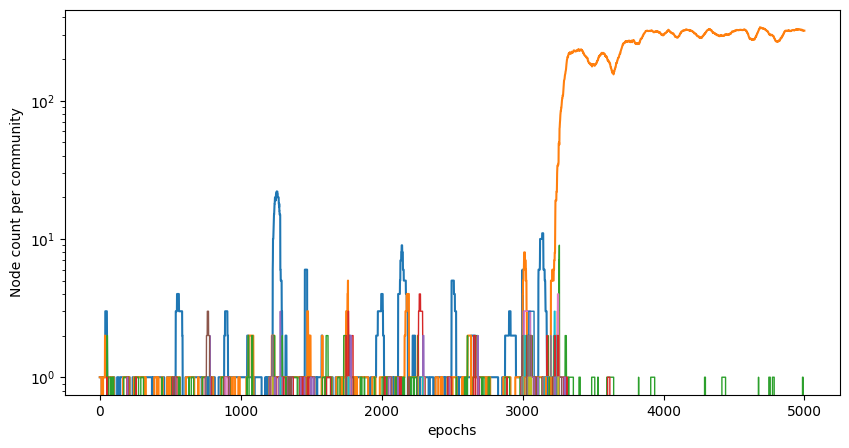

In [24]:
f = plt.figure(figsize=(10, 5))
for i in range(scta.MIN_CLUSTER_ID, scta.MAX_CLUSTER_ID):
    if np.max(scta.count_per_sync_cluster[:,i]) > 10:
        plt.plot(np.linspace(0, scta.window_size-1, scta.window_size), 
                 scta.count_per_sync_cluster[:,i], label=""+str(i))
    else:
        plt.plot(np.linspace(0, scta.window_size-1, scta.window_size), 
                 scta.count_per_sync_cluster[:,i], linewidth=1)

plt.xlabel("epochs")
plt.ylabel("Node count per community")
plt.yscale("log")
plt.show()

In [25]:
whole_toe_df.head()

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,3306.0,4999.0,3424.0,4984.0,4999.0,4999.0,4963.0,4978.0,4977.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0


In [29]:
scta.node_communities.shape

(5000, 426)

/tmp/ipykernel_896838/48589568.py:2: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  (l_toe_df.loc[t].append(r_toe_df.loc[t])).sort_values().plot(kind='hist', cumulative=True, bins=100, histtype=u'step')


(0.0, 5000.0)

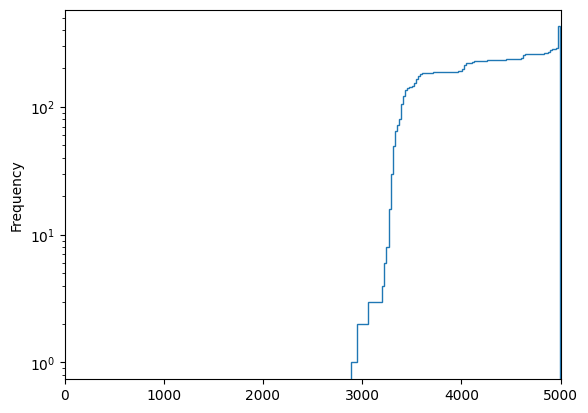

In [43]:
t = 4
(l_toe_df.loc[t].append(r_toe_df.loc[t])).sort_values().plot(kind='hist', cumulative=True, bins=100, histtype=u'step')
plt.yscale('log')
plt.xlim(0, 5000)

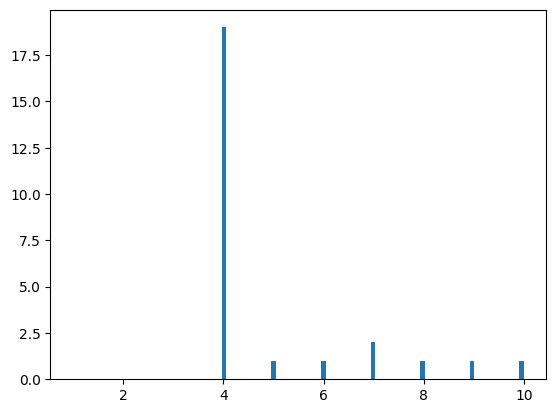

In [28]:
plt.hist(scta.node_communities[3280, :], bins=100, range=(1, 10));

In [72]:
np.where(scta.node_communities[:, 2]==4)[0][0]

3424

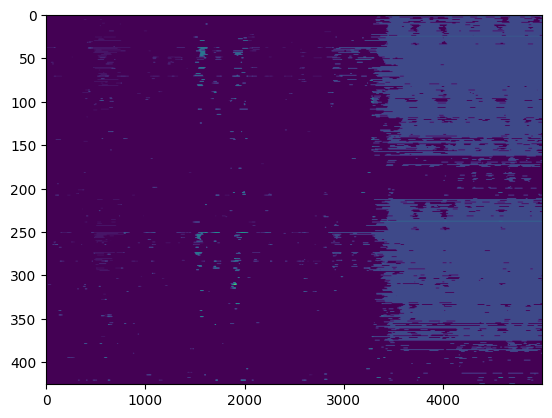

In [74]:
plt.imshow(scta.node_communities.T, aspect='auto')

# Plotting TOE

In [3]:
import pandas as  pd 
import matplotlib.pyplot as plt

In [5]:
df_toe_fn  = pd.read_pickle(r'toe_10_fn.bz2',compression='bz2')
df_toe_fn.head(10)

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,4941.0,4999.0,4999.0,4999.0,4973.0,4999.0,4962.0,4999.0,4976.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
1,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
2,3353.0,4908.0,4861.0,4999.0,4910.0,4909.0,4916.0,4902.0,4885.0,4930.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4912.0,4999.0,4999.0,4999.0,4899.0
3,3135.0,4999.0,3595.0,4999.0,4685.0,3840.0,4876.0,4888.0,3399.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
4,3306.0,4999.0,3424.0,4984.0,4999.0,4999.0,4963.0,4978.0,4977.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
5,3358.0,4987.0,3403.0,4935.0,4895.0,4964.0,3443.0,3426.0,3400.0,4917.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4964.0,4999.0,4999.0,4999.0,4971.0
6,3405.0,4999.0,4597.0,4929.0,4917.0,4929.0,3405.0,4899.0,4886.0,4944.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4967.0,4999.0,4999.0,4999.0,4999.0
7,3115.0,4999.0,3613.0,4999.0,4280.0,4991.0,3498.0,4132.0,4294.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
8,3405.0,4999.0,4867.0,4999.0,4883.0,4999.0,4999.0,4843.0,4862.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
9,3524.0,4326.0,3561.0,4949.0,3603.0,3656.0,3579.0,3586.0,3675.0,4928.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4897.0,4999.0,4999.0,4999.0,4929.0


In [6]:
df_toe_peri  = pd.read_pickle(r'toe_10_peri.bz2',compression='bz2')
df_toe_peri.head(10)

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,3294.0,4936.0,3647.0,4942.0,4999.0,4823.0,4646.0,4905.0,3651.0,4886.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
1,3718.0,4999.0,4966.0,4999.0,4999.0,4999.0,4999.0,4999.0,4970.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
2,4828.0,4999.0,4819.0,4999.0,4999.0,4999.0,4999.0,4999.0,4832.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
3,3387.0,4916.0,4531.0,4999.0,4821.0,4887.0,4822.0,4826.0,4854.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
4,3372.0,4999.0,3448.0,4880.0,3565.0,4784.0,3453.0,4797.0,3535.0,4787.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
5,3364.0,4941.0,3524.0,4964.0,4999.0,4092.0,4928.0,4185.0,4023.0,4973.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
6,3302.0,4999.0,4956.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
7,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
8,3446.0,4999.0,3483.0,4999.0,4999.0,4999.0,4941.0,4908.0,4186.0,4999.0,...,4999.0,4999.0,4974.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
9,4801.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0


In [7]:
df_toe_fn[0]

0    4941.0
1    4999.0
2    3353.0
3    3135.0
4    3306.0
5    3358.0
6    3405.0
7    3115.0
8    3405.0
9    3524.0
Name: 0, dtype: float32

In [29]:
noi_mean=[]
noi_median=[]
for i in [36,249,53,266,64,277,23,236,43,256]:
    noi_mean.append(df_toe_fn[i].mean())
    noi_median.append(df_toe_fn[i].median())   

In [30]:
#putting first two elements as zero as 1st entry is for full network
peri_mean=[0,0]
peri_median=[0,0]
for i in [53,266,64,277,23,236,43,256]:
    peri_mean.append(df_toe_peri[i].mean())
    peri_median.append(df_toe_peri[i].median()) 

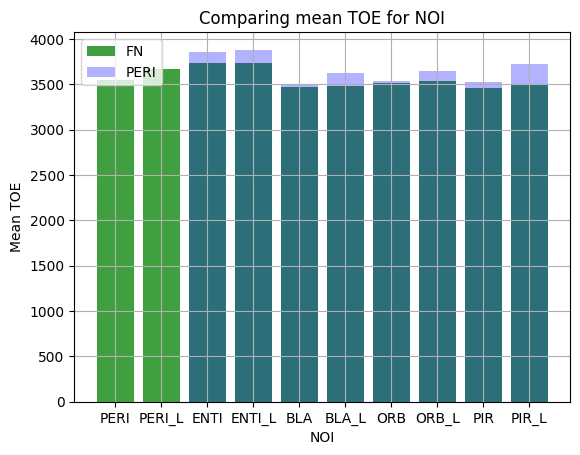

In [31]:
labels = ['PERI','PERI_L','ENTI','ENTI_L','BLA','BLA_L','ORB','ORB_L','PIR','PIR_L']
plt.bar(labels,noi_mean,color='g', alpha=0.75,label='FN')
plt.bar(labels,peri_mean,color='b', alpha=0.3,label='PERI')
plt.title('Comparing mean TOE for NOI')
plt.xlabel("NOI")
plt.ylabel("Mean TOE")
plt.legend()
plt.grid(True)
plt.show()

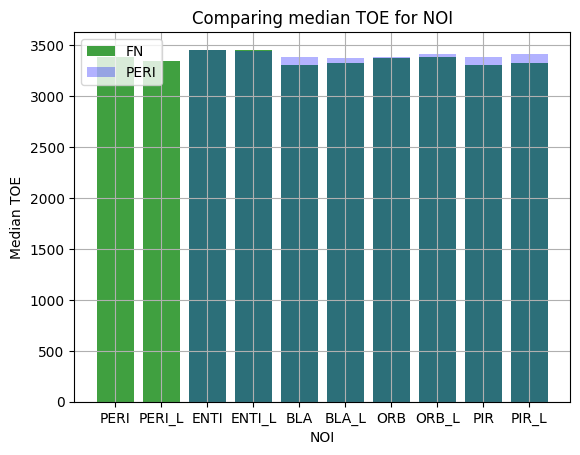

In [32]:
labels = ['PERI','PERI_L','ENTI','ENTI_L','BLA','BLA_L','ORB','ORB_L','PIR','PIR_L']
plt.bar(labels,noi_median,color='g', alpha=0.75,label='FN')
plt.bar(labels,peri_median,color='b', alpha=0.3,label='PERI')
plt.title('Comparing median TOE for NOI')
plt.xlabel("NOI")
plt.ylabel("Median TOE")
plt.legend()
plt.grid(True)
plt.show()

#### Average time of entry for all nodes in the full network vs dropout network (remember, we hypothesized that when some node is removed, it might make it harder for another region that it is connected to to become part of the sync cluster...)mm

In [33]:
noi_mean=[]
noi_median=[]
for i in list(range(0,426)):
    noi_mean.append(df_toe_fn[i].mean())
    noi_median.append(df_toe_fn[i].median())   

In [35]:
len(noi_mean)

426

In [39]:
peri_mean=[]
peri_median=[]
for i in list(range(0,426)):
    peri_mean.append(df_toe_peri[i].mean())
    peri_median.append(df_toe_peri[i].median()) 

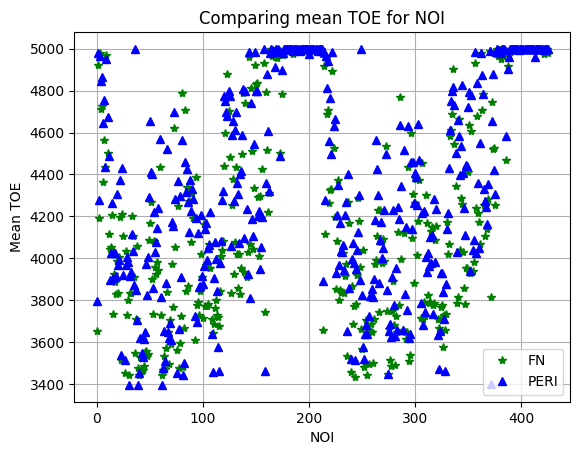

In [54]:
labels = list(range(0,426))
plt.plot(labels, noi_mean,'g*',label='FN')
plt.plot(labels,peri_mean,'b^',label='PERI')
plt.title('Comparing mean TOE for NOI')
plt.xlabel("NOI")
plt.ylabel("Mean TOE")
plt.legend()
plt.grid(True)
plt.show()

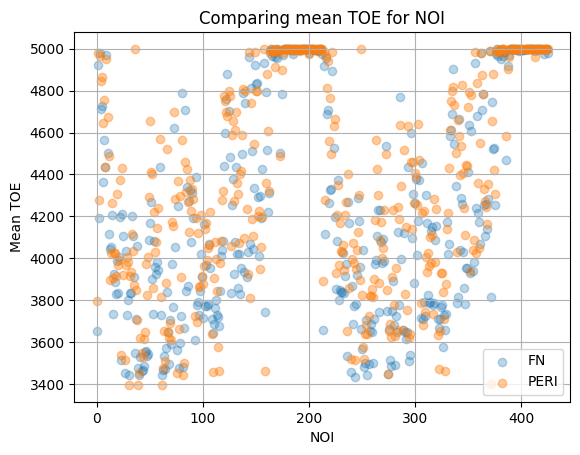

In [57]:
labels = list(range(0,426))
plt.scatter(labels, noi_mean,alpha=0.3,label='FN')
plt.scatter(labels,peri_mean,alpha=0.4,label='PERI')
plt.title('Comparing mean TOE for NOI')
plt.xlabel("NOI")
plt.ylabel("Mean TOE")
plt.legend()
plt.grid(True)
plt.show()

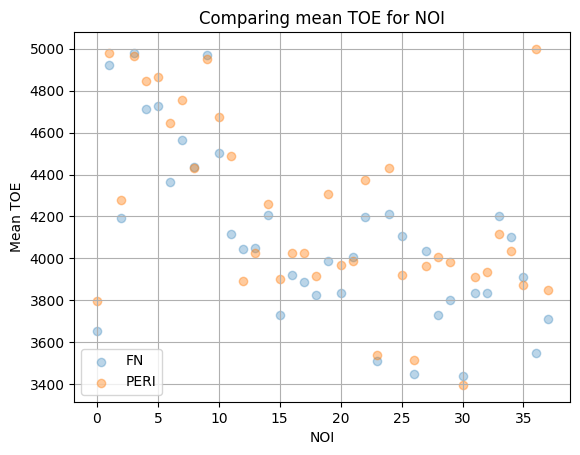

In [58]:
labels = list(range(0,426))
plt.scatter(labels[0:38], noi_mean[0:38],alpha=0.3,label='FN')
plt.scatter(labels[0:38],peri_mean[0:38],alpha=0.4,label='PERI')
plt.title('Comparing mean TOE for NOI')
plt.xlabel("NOI")
plt.ylabel("Mean TOE")
plt.legend()
plt.grid(True)
plt.show()

#### Load data

In [ ]:
df_toe_fn  = pd.read_pickle(r'toe_fn_20.bz2',compression='bz2')

In [ ]:
df_nc_fn = pd.read_pickle(r'nc_fn_20.bz2',compression='bz2')

In [60]:
len(peri_mean)

426

In [61]:
len(noi_mean)

426

In [91]:
# Sample lists

result = [b-a for a, b in zip(fn_mean, peri_mean)]

#print("Result using list comprehension:", result)


(array([  1.,   1.,   4.,   5.,   2.,  14.,   9.,  13.,  22.,  27., 120.,
         46.,  36.,  33.,  32.,  11.,  14.,  13.,   5.,   8.,   2.,   1.,
          2.,   2.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   1.]),
 array([-380.5  , -344.996, -309.492, -273.988, -238.484, -202.98 ,
        -167.476, -131.972,  -96.468,  -60.964,  -25.46 ,   10.044,
          45.548,   81.052,  116.556,  152.06 ,  187.564,  223.068,
         258.572,  294.076,  329.58 ,  365.084,  400.588,  436.092,
         471.596,  507.1  ,  542.604,  578.108,  613.612,  649.116,
         684.62 ,  720.124,  755.628,  791.132,  826.636,  862.14 ,
         897.644,  933.148,  968.652, 1004.156, 1039.66 , 1075.164,
        1110.668, 1146.172, 1181.676, 1217.18 , 1252.684, 1288.188,
        1323.692, 1359.196, 1394.7  ]),
 <BarContainer object of 50 artists>)

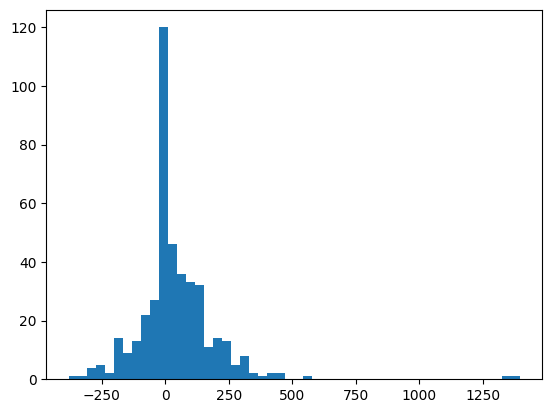

In [90]:
plt.hist(result, bins=50)

In [92]:
result = [b-a for a, b in zip(fn_mean, re_mean)]

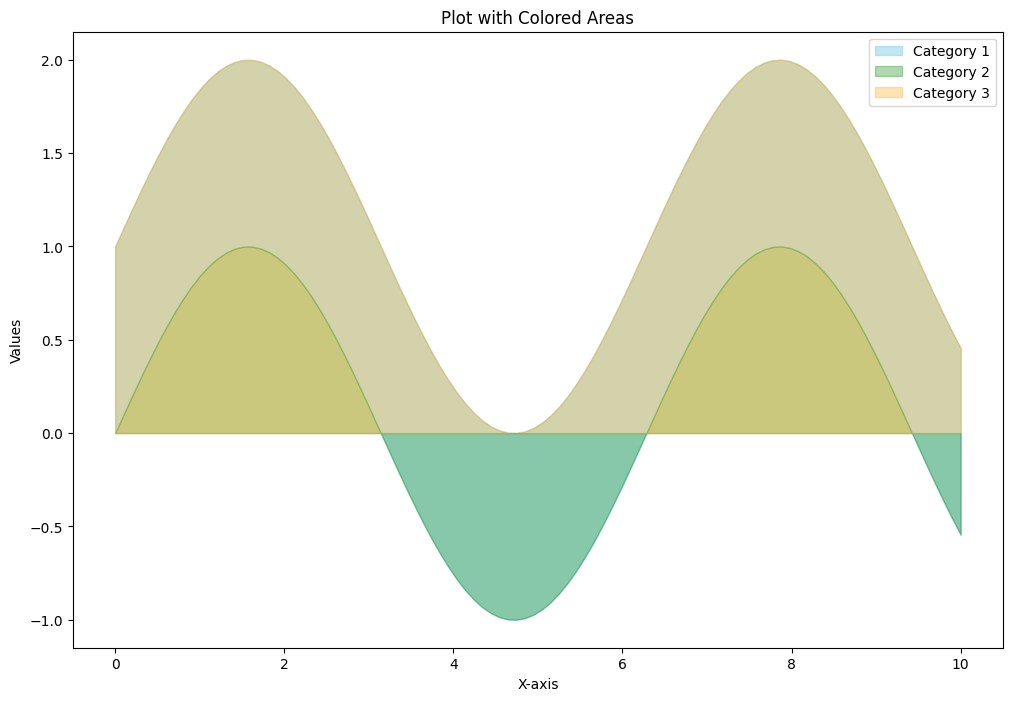

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.sin(x) + 1

# Create the plot
plt.figure(figsize=(12, 8))

# Fill area between y1 and y2 for Category 1
plt.fill_between(x, y1, y2, where=(y2 >= y1), interpolate=True, color='skyblue', alpha=0.5, label='Category 1')

# Fill area below y1 for Category 2
plt.fill_between(x, y1, color='green', alpha=0.3, label='Category 2')

# Fill area above y2 for Category 3
plt.fill_between(x, y2, color='orange', alpha=0.3, label='Category 3')

# Add labels and legend
plt.xlabel('X-axis')
plt.ylabel('Values')
plt.title('Plot with Colored Areas')
plt.legend()

# Show the plot
plt.show()


